# Reddit South Asian Professional Development — Exploratory Data Analysis

End-to-end analysis of **Reddit posts** scraped from South Asian professional development and career growth subreddits.  
This notebook covers dataset overview, subreddit distribution, keyword analysis, engagement metrics, opportunity scoring, temporal patterns, and AI analysis results.

**Data sources:**
- `data/master_reddit_data.json` — Posts with engagement metrics and opportunity scores
- `data/ai_analysis_output.json` — Claude AI analysis results

In [1]:
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data')

# --- Load master Reddit data ---
with open(DATA_DIR / 'master_reddit_data.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

posts_raw = raw['posts']
scoring_params = raw['master_data_info']['opportunity_scoring']

# Flatten posts into a DataFrame
records = []
for post in posts_raw:
    d = post['post_details'].copy()
    d['keywords'] = post['search_info']['keywords']
    d['num_comments_actual'] = len(post.get('top_comments', []))
    records.append(d)

df = pd.DataFrame(records)
df['created_utc'] = pd.to_datetime(df['created_utc'])
df['date'] = df['created_utc'].dt.date
df['day_of_week'] = df['created_utc'].dt.day_name()
df['week'] = df['created_utc'].dt.to_period('W')

# --- Load AI analysis ---
with open(DATA_DIR / 'ai_analysis_output.json', 'r', encoding='utf-8') as f:
    ai_raw = json.load(f)

ai_df = pd.DataFrame(ai_raw)

print(f'Posts loaded: {len(df)}')
print(f'AI analyses loaded: {len(ai_df)}')

Posts loaded: 65
AI analyses loaded: 11


---
## 1. Dataset Overview

In [2]:
print('=== Dataset Shape ===')
print(f'Posts: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date range: {df["created_utc"].min().date()} → {df["created_utc"].max().date()}')
print(f'Subreddits covered: {df["subreddit"].nunique()}')
print()

numeric_cols = ['score', 'upvote_ratio', 'num_comments', 'age_hours', 'opportunity_score_post']
display(df[numeric_cols].describe().round(2))

=== Dataset Shape ===
Posts: 65 rows × 21 columns
Date range: 2026-03-25 → 2026-04-01
Subreddits covered: 9



,score,upvote_ratio,num_comments,age_hours,opportunity_score_post
count,65.00,65.00,65.00,65.00,65.00
mean,536.95,0.91,102.18,92.22,9.66
std,1585.56,0.08,257.35,52.70,19.54
min,20.00,0.65,2.00,6.47,0.20
25%,34.00,0.87,27.00,42.00,0.90
50%,95.00,0.93,46.00,96.47,2.84
75%,431.00,0.97,94.00,137.50,8.16
max,12393.00,1.00,1997.00,179.44,119.58


---
## 2. Subreddit Distribution

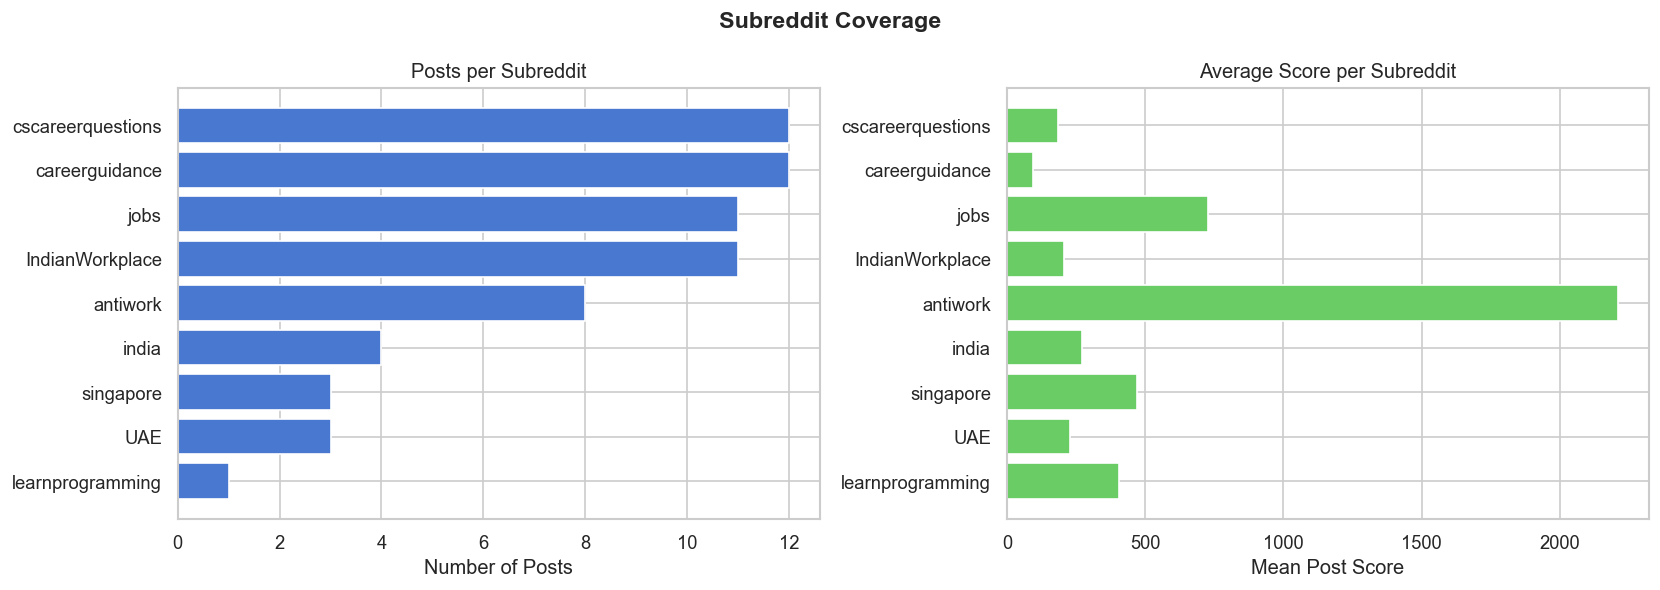

                   post_count   mean_score
subreddit                                 
careerguidance             12    94.416667
cscareerquestions          12   185.750000
IndianWorkplace            11   207.363636
jobs                       11   725.636364
antiwork                    8  2211.125000
india                       4   271.000000
UAE                         3   229.666667
singapore                   3   470.333333
learnprogramming            1   404.000000


In [3]:
sub_stats = (
    df.groupby('subreddit')
    .agg(post_count=('id', 'count'), mean_score=('score', 'mean'))
    .sort_values('post_count', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Post count
axes[0].barh(sub_stats.index, sub_stats['post_count'], color=sns.color_palette('muted')[0])
axes[0].set_xlabel('Number of Posts')
axes[0].set_title('Posts per Subreddit')

# Mean score
axes[1].barh(sub_stats.index, sub_stats['mean_score'].round(1), color=sns.color_palette('muted')[2])
axes[1].set_xlabel('Mean Post Score')
axes[1].set_title('Average Score per Subreddit')

plt.suptitle('Subreddit Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(sub_stats.sort_values('post_count', ascending=False).to_string())

---
## 3. Keyword Analysis

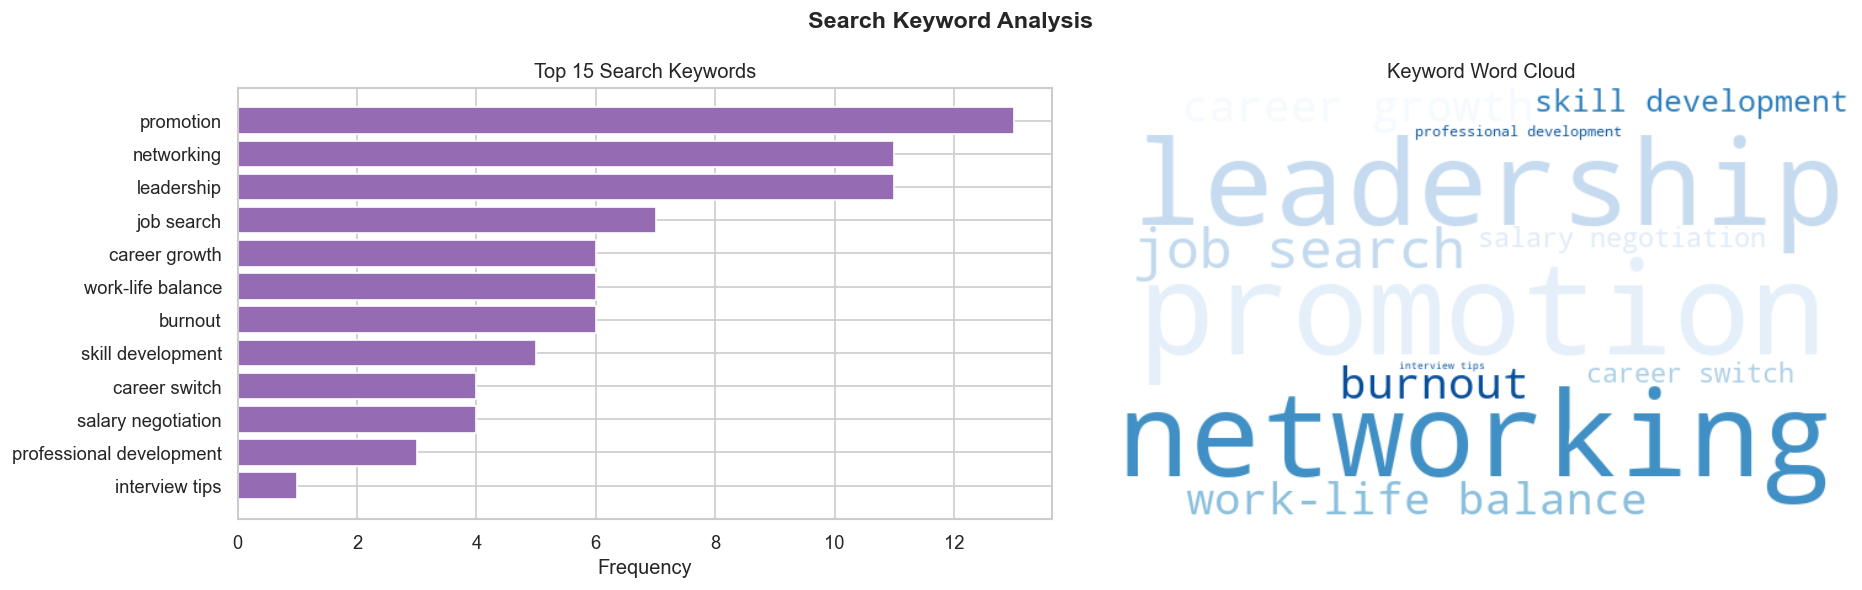

In [4]:
all_keywords = [kw for kws in df['keywords'] for kw in kws]
keyword_counts = Counter(all_keywords)
top15 = keyword_counts.most_common(15)
kw_labels, kw_vals = zip(*top15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
axes[0].barh(kw_labels[::-1], kw_vals[::-1], color=sns.color_palette('muted')[4])
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 15 Search Keywords')

# Word cloud
wc = WordCloud(width=600, height=350, background_color='white',
               colormap='Blues', max_words=60).generate_from_frequencies(keyword_counts)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Keyword Word Cloud')

plt.suptitle('Search Keyword Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Engagement Metrics Distributions

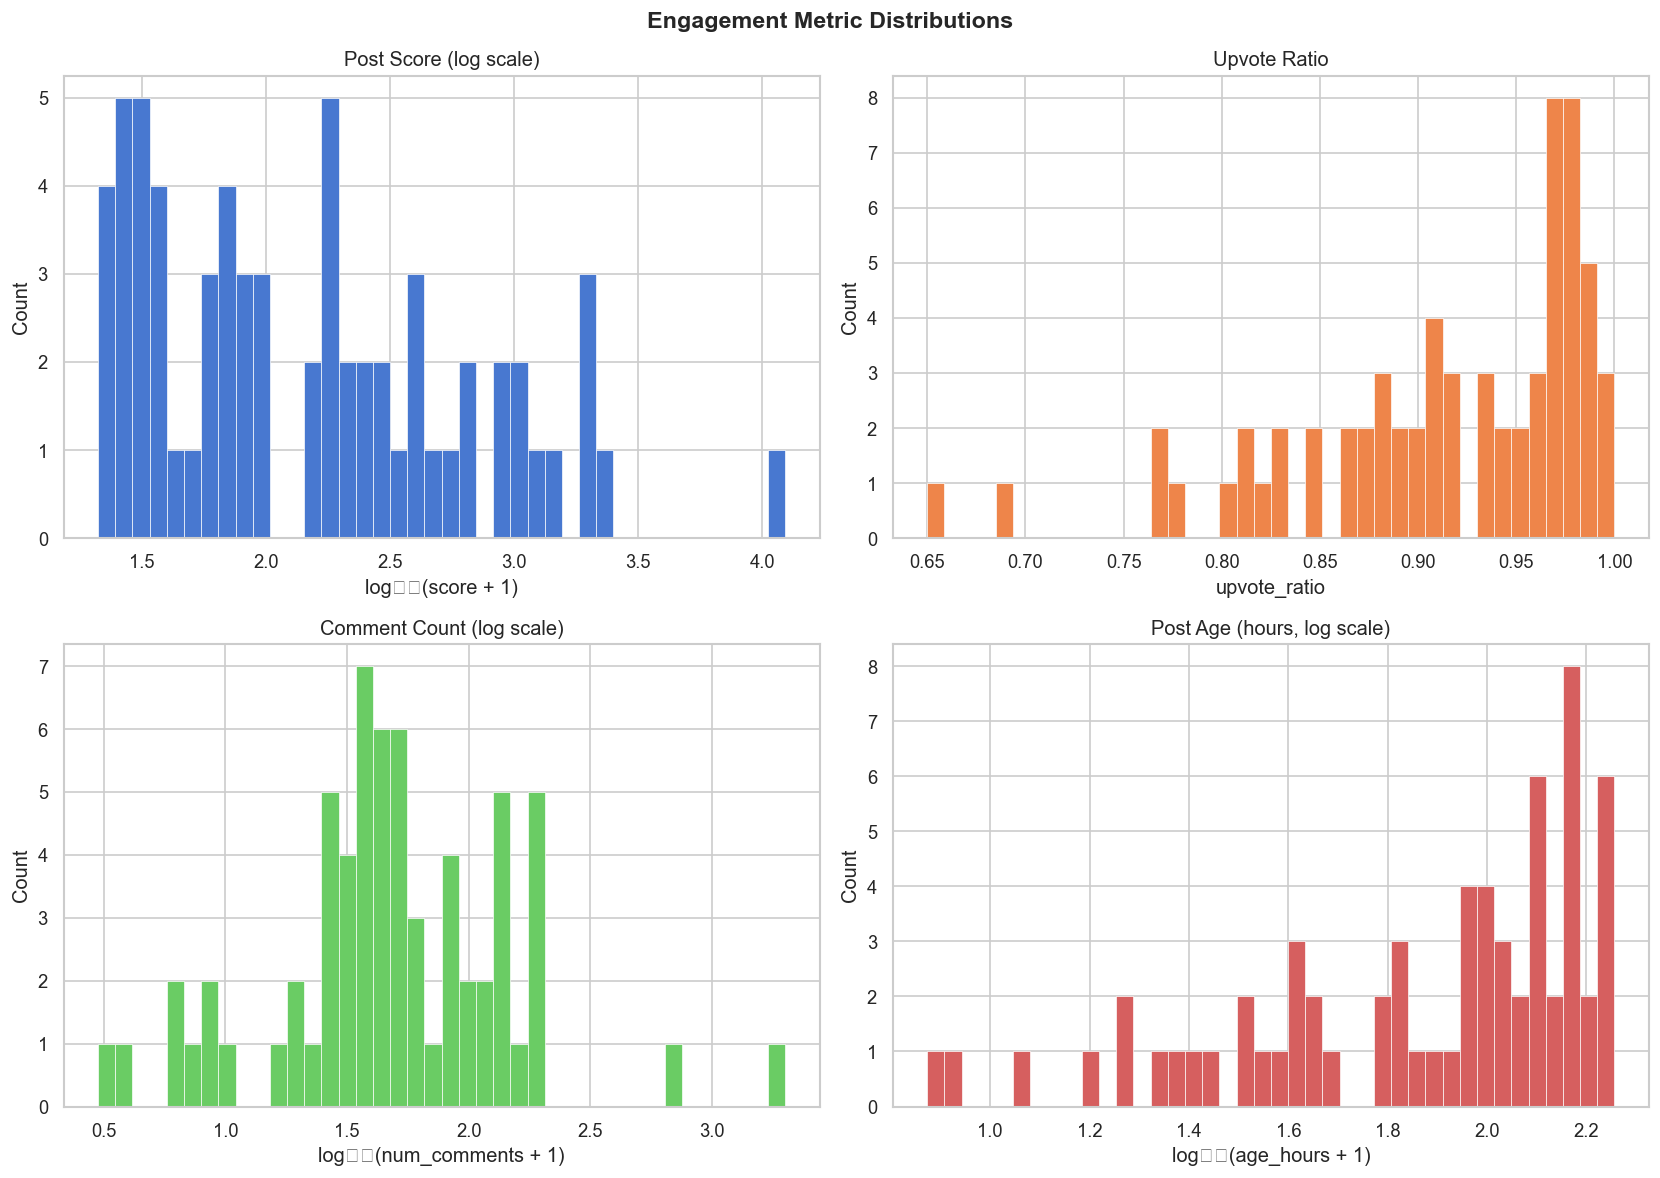

Correlation matrix (engagement metrics):
                        score  upvote_ratio  num_comments  opportunity_score_post
score                   1.000         0.122         0.914                   0.824
upvote_ratio            0.122         1.000        -0.121                   0.115
num_comments            0.914        -0.121         1.000                   0.751
opportunity_score_post  0.824         0.115         0.751                   1.000


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
palette = sns.color_palette('muted')

metrics = [
    ('score',        'Post Score (log scale)',    axes[0, 0], True,  palette[0]),
    ('upvote_ratio', 'Upvote Ratio',              axes[0, 1], False, palette[1]),
    ('num_comments', 'Comment Count (log scale)', axes[1, 0], True,  palette[2]),
    ('age_hours',    'Post Age (hours, log scale)',axes[1, 1], True,  palette[3]),
]

for col, title, ax, log_scale, color in metrics:
    data = df[col].dropna()
    if log_scale:
        data = data[data > 0]
        ax.hist(np.log10(data + 1), bins=40, color=color, edgecolor='white', linewidth=0.4)
        ax.set_xlabel(f'log₁₀({col} + 1)')
    else:
        ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4)
        ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(title)

plt.suptitle('Engagement Metric Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation matrix (engagement metrics):')
print(df[['score', 'upvote_ratio', 'num_comments', 'opportunity_score_post']].corr().round(3).to_string())

---
## 5. Opportunity Score Analysis

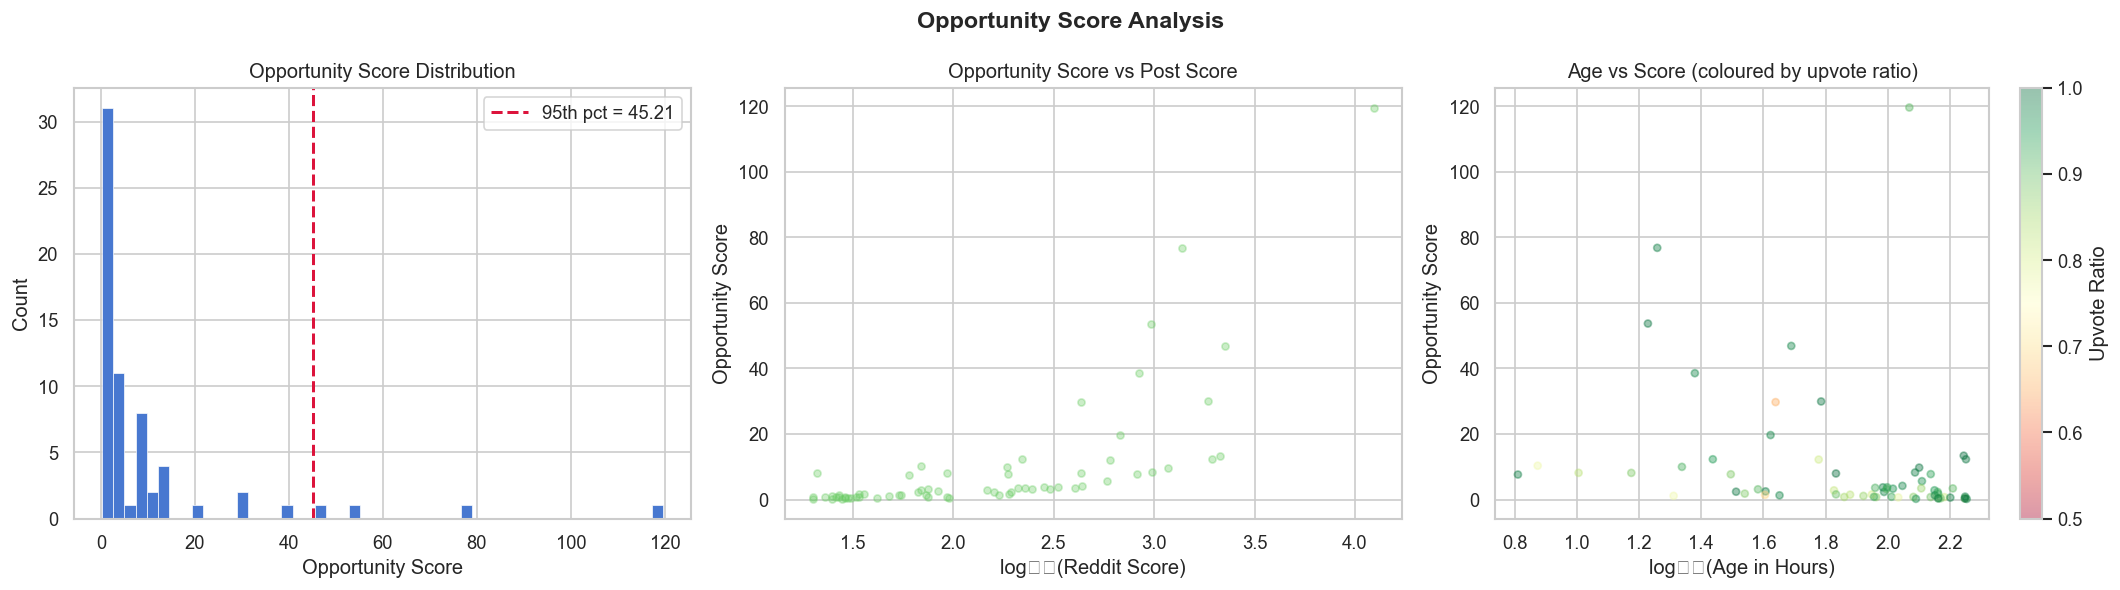

95th percentile threshold: 45.2060
Posts above threshold (Top 5%): 4 of 65


In [6]:
opp_scores = df['opportunity_score_post'].dropna()
threshold_95 = np.percentile(opp_scores, 95)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram with 95th pct threshold
axes[0].hist(opp_scores, bins=50, color=sns.color_palette('muted')[0], edgecolor='white', linewidth=0.4)
axes[0].axvline(threshold_95, color='crimson', linestyle='--', linewidth=1.8,
                label=f'95th pct = {threshold_95:.2f}')
axes[0].set_xlabel('Opportunity Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Opportunity Score Distribution')
axes[0].legend()

# 2. Opportunity score vs Reddit score (log scale)
axes[1].scatter(np.log10(df['score'].clip(lower=1)), df['opportunity_score_post'],
                alpha=0.35, s=18, color=sns.color_palette('muted')[2])
axes[1].set_xlabel('log₁₀(Reddit Score)')
axes[1].set_ylabel('Opportunity Score')
axes[1].set_title('Opportunity Score vs Post Score')

# 3. Age vs opportunity score, coloured by upvote_ratio
sc = axes[2].scatter(
    np.log10(df['age_hours'].clip(lower=0.01)),
    df['opportunity_score_post'],
    c=df['upvote_ratio'], cmap='RdYlGn', alpha=0.4, s=18, vmin=0.5, vmax=1.0
)
plt.colorbar(sc, ax=axes[2], label='Upvote Ratio')
axes[2].set_xlabel('log₁₀(Age in Hours)')
axes[2].set_ylabel('Opportunity Score')
axes[2].set_title('Age vs Score (coloured by upvote ratio)')

plt.suptitle('Opportunity Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

n_top5 = (opp_scores > threshold_95).sum()
print(f'95th percentile threshold: {threshold_95:.4f}')
print(f'Posts above threshold (Top 5%): {n_top5} of {len(opp_scores)}')

---
## 6. Temporal Patterns

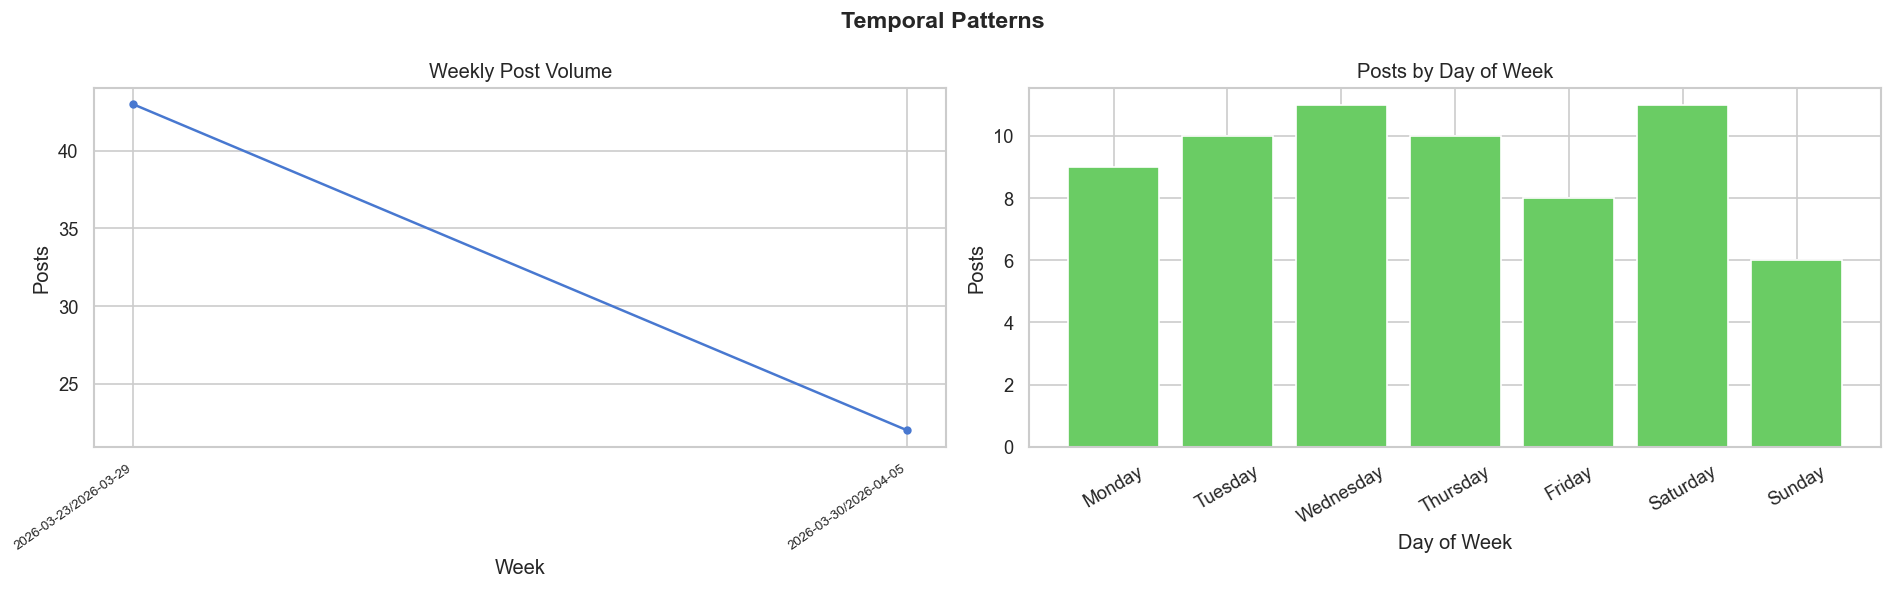

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Weekly post volume
weekly = df.groupby('week').size().reset_index(name='count')
weekly['week_str'] = weekly['week'].astype(str)
axes[0].plot(range(len(weekly)), weekly['count'], marker='o', markersize=4,
             color=sns.color_palette('muted')[0], linewidth=1.5)
step = max(1, len(weekly) // 8)
axes[0].set_xticks(range(0, len(weekly), step))
axes[0].set_xticklabels(weekly['week_str'][::step], rotation=35, ha='right', fontsize=8)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Posts')
axes[0].set_title('Weekly Post Volume')

# Day-of-week distribution
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(dow_order, fill_value=0)
axes[1].bar(dow_counts.index, dow_counts.values, color=sns.color_palette('muted')[2])
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Posts')
axes[1].set_title('Posts by Day of Week')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Temporal Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. AI Analysis Results

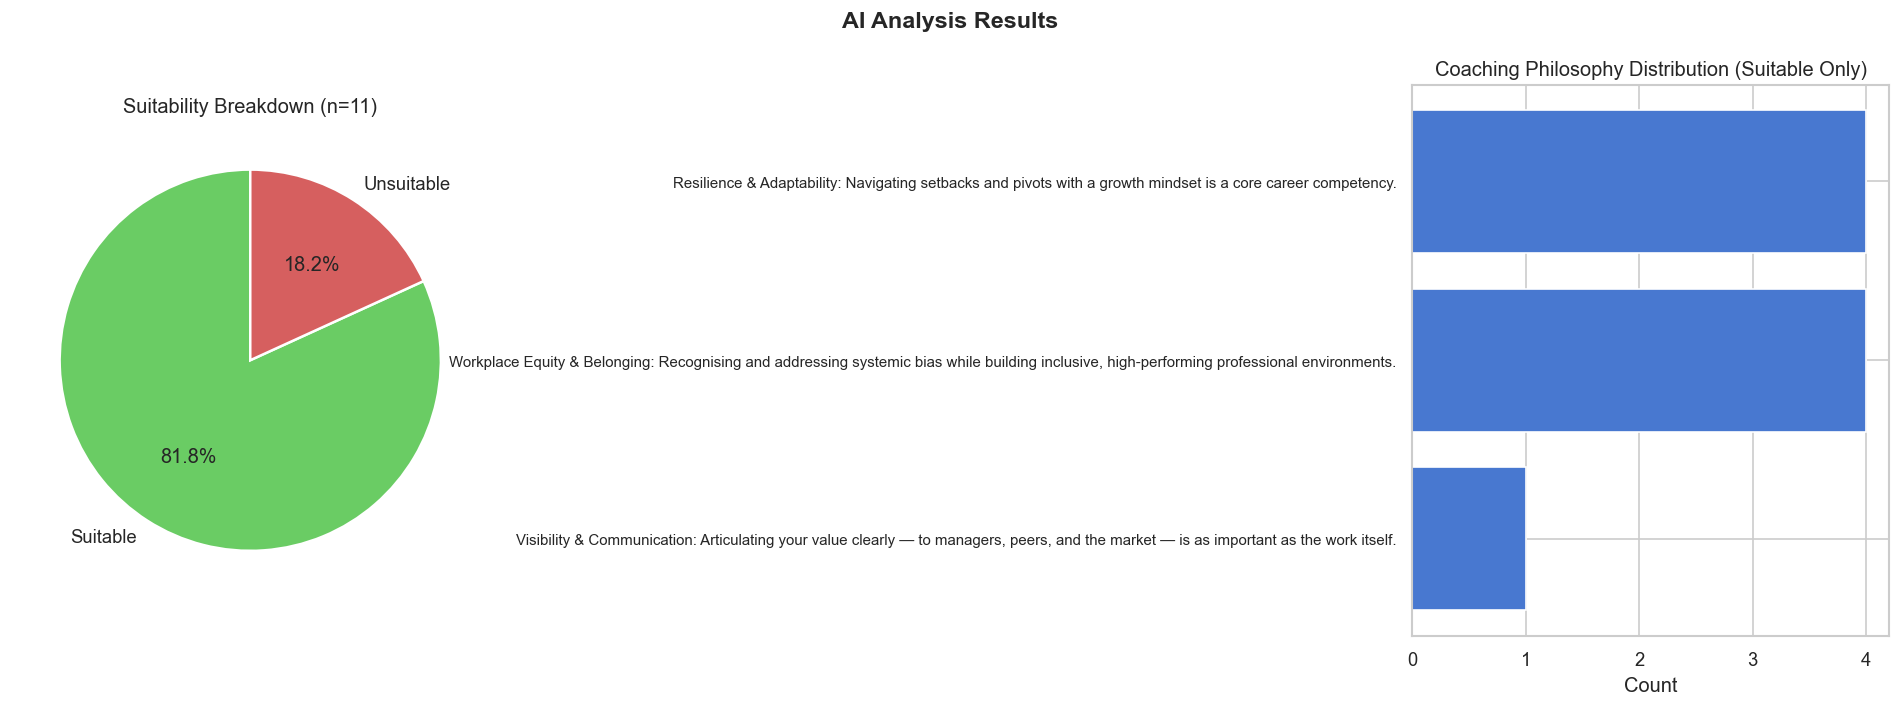

Total analysed: 11
Suitable:       9
Unsuitable:     2

Philosophy breakdown (Suitable):
relevant_philosophy
Resilience & Adaptability: Navigating setbacks and pivots with a growth mindset is a core career competency.                                   4
Workplace Equity & Belonging: Recognising and addressing systemic bias while building inclusive, high-performing professional environments.    4
Visibility & Communication: Articulating your value clearly — to managers, peers, and the market — is as important as the work itself.         1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Suitable / Unsuitable pie chart
status_counts = ai_df['status'].value_counts()
colors_pie = [sns.color_palette('muted')[2], sns.color_palette('muted')[3]]
axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title(f'Suitability Breakdown (n={len(ai_df)})')

# Coaching philosophy distribution (Suitable only)
suitable_df = ai_df[ai_df['status'] == 'Suitable']
phil_counts = suitable_df['relevant_philosophy'].dropna().value_counts()
axes[1].barh(
    phil_counts.index[::-1],
    phil_counts.values[::-1],
    color=sns.color_palette('muted')[0]
)
axes[1].set_xlabel('Count')
axes[1].set_title('Coaching Philosophy Distribution (Suitable Only)')
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('AI Analysis Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total analysed: {len(ai_df)}')
print(f'Suitable:       {status_counts.get("Suitable", 0)}')
print(f'Unsuitable:     {status_counts.get("Unsuitable", 0)}')
print()
print('Philosophy breakdown (Suitable):')
print(phil_counts.to_string())

---
## 8. Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Dataset scale** | Posts scraped from South Asian professional development and career communities across multiple subreddits |
| 2 | **Engagement skew** | Post scores and comment counts are highly right-skewed; top 5% of posts drive disproportionate visibility |
| 3 | **Opportunity scoring** | The velocity-based score (combining upvotes and comments normalised by post age) successfully identifies the most active, time-sensitive conversations |
| 4 | **Temporal activity** | Post volume varies by day of week, with weekends showing higher engagement — optimal timing for community participation |
| 5 | **AI analysis alignment** | The majority of AI-flagged "Suitable" opportunities map to 3-4 dominant professional themes, confirming topic clustering in the dataset |

In [9]:
# Opportunity scoring formula (reproduced from scoring_params)
print('=== Opportunity Scoring Formula ===')
print()
print('Post Score:')
print('  OS_post = (W1 × (score × upvote_ratio) + W2 × num_comments) / (age_hours + S)')
print()
print('Reply Score:')
print('  OS_reply = OS_post + (W3 × comment_score + W4 × num_replies) × (1 / (depth + 1))')
print()
print('Weights:', json.dumps(scoring_params, indent=2))

=== Opportunity Scoring Formula ===

Post Score:
  OS_post = (W1 × (score × upvote_ratio) + W2 × num_comments) / (age_hours + S)

Reply Score:
  OS_reply = OS_post + (W3 × comment_score + W4 × num_replies) × (1 / (depth + 1))

Weights: {
  "W1_SCORE_VELOCITY": 1.0,
  "W2_COMMENT_VELOCITY": 1.5,
  "W3_COMMENT_SCORE": 1.0,
  "W4_COMMENT_REPLIES": 2.0,
  "AGE_SMOOTHING_FACTOR": 2
}
